In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from functools import reduce
from typing import Tuple, List, Dict

In [50]:

df = pd.read_csv('processed_weather_data.csv')
df['date_of_record'] = pd.to_datetime(df['date_of_record'])
df

,date_of_record,month,season,station_name,state,district,avg_temp,min_temp,max_temp,wind_speed,...,vorticity,coriolis,kinetic_energy,temp_gradient,rain_lag_1,rain_lag_3,rain_lag_7,rain_lag_30,month_sin,month_cos
0,2015-01-02,1,Winter,Agartala,TR,West Tripura,23.1,18.600000,30.3,2.6,...,0.000000,0.000059,4.034195,0.0,0.0,0.0,0.0,0.0,0.500000,0.866025
1,2015-01-17,1,Winter,Agartala,TR,West Tripura,20.4,18.593333,27.4,2.6,...,0.000000,0.000059,4.071301,-2.7,0.0,0.0,0.0,0.0,0.500000,0.866025
2,2015-01-18,1,Winter,Agartala,TR,West Tripura,15.8,18.586667,17.0,2.6,...,0.000000,0.000059,4.136115,-4.6,0.3,0.0,0.0,0.0,0.500000,0.866025
3,2015-01-19,1,Winter,Agartala,TR,West Tripura,15.2,18.580000,17.7,2.6,...,0.000000,0.000059,4.144721,-0.6,2.0,0.0,0.0,0.0,0.500000,0.866025
4,2015-02-15,2,Winter,Agartala,TR,West Tripura,19.7,18.573333,27.0,2.6,...,0.000000,0.000059,4.081032,4.5,0.0,0.3,0.0,0.0,0.866025,0.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
712780,2025-02-06,2,Winter,Yercaud,TN,Salem,16.7,11.000000,24.0,9.1,...,-0.465242,0.000030,50.400577,-0.9,0.0,0.0,0.4,1.1,0.866025,0.500000
712781,2025-02-07,2,Winter,Yercaud,TN,Salem,17.2,11.800000,24.6,8.8,...,0.232621,0.000030,47.106833,0.5,0.0,0.0,1.1,0.0,0.866025,0.500000
712782,2025-02-08,2,Winter,Yercaud,TN,Salem,17.5,12.400000,24.3,9.6,...,-0.620323,0.000030,56.008684,0.3,0.0,0.0,0.3,0.0,0.866025,0.500000
712783,2025-02-09,2,Winter,Yercaud,TN,Salem,17.7,12.400000,24.3,10.8,...,-0.930484,0.000030,70.802314,0.2,0.0,0.0,0.0,0.4,0.866025,0.500000


In [115]:
len(df.station_name.unique())

406

In [51]:
df.columns

Index(['date_of_record', 'month', 'season', 'station_name', 'state',
       'district', 'avg_temp', 'min_temp', 'max_temp', 'wind_speed',
       'air_pressure', 'elevation', 'latitude', 'longitude', 'rainfall',
       'temp_k', 'pressure_pa', 'air_density', 'lat_rad', 'u_velocity',
       'v_velocity', 'pressure_gradient', 'du_dx', 'dv_dy', 'divergence',
       'dv_dx', 'du_dy', 'vorticity', 'coriolis', 'kinetic_energy',
       'temp_gradient', 'rain_lag_1', 'rain_lag_3', 'rain_lag_7',
       'rain_lag_30', 'month_sin', 'month_cos'],
      dtype='object')

In [52]:
from typing import Tuple
def filter_date_range(
    df: pd.DataFrame,
    start: str,
    end: str
) -> pd.DataFrame:
    """Return rows whose date_of_record falls in [start, end]."""
    mask = (df["date_of_record"] >= start) & (df["date_of_record"] <= end)
    return df.loc[mask].copy()


def train_test_split_time(
    df: pd.DataFrame,
    train_start: str = "2015-01-01",
    train_end:   str = "2023-12-31",
    test_start:  str = "2024-01-01",
    test_end:    str = None,  # till latest
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Time-based split:
    - Train: [train_start, train_end]
    - Test:  [test_start, test_end]
    """

    # Train split
    train_df = filter_date_range(df, train_start, train_end)

    # Test split
    if test_end:
        test_df = filter_date_range(df, test_start, test_end)
    else:
        test_df = df[df["date_of_record"] >= test_start].copy()

    print(f"✔ Train: {train_start} → {train_end}  ({len(train_df):,} rows)")
    print(f"✔ Test : {test_start} → {test_df['date_of_record'].max()}  ({len(test_df):,} rows)")

    return train_df, test_df



In [53]:
train_df, test_df = train_test_split_time(df)

✔ Train: 2015-01-01 → 2023-12-31  (548,483 rows)
✔ Test : 2024-01-01 → 2025-02-10 00:00:00  (164,302 rows)


In [116]:
len(train_df.station_name.unique()), len(test_df.station_name.unique())

(406, 404)

In [119]:
np.savetxt("station_names.txt", train_df.station_name.unique(), fmt="%s")

In [54]:
FEATURES = [
    "avg_temp", "min_temp", "max_temp", "wind_speed", "air_pressure",
    "air_density", "u_velocity", "v_velocity", "pressure_gradient",
    "divergence", "vorticity", "kinetic_energy", "temp_gradient",
    "rain_lag_1", "rain_lag_3", "rain_lag_7", "rain_lag_30",
    "month_sin", "month_cos"
]

TARGET = 'rainfall'

In [55]:

X_train = train_df[FEATURES]
y_train = train_df[TARGET]

X_test  = test_df[FEATURES]
y_test  = test_df[TARGET]



In [56]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((548483, 19), (548483,), (164302, 19), (164302,))

In [57]:
from sklearn.base import RegressorMixin
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error
def evaluate_model(model : type[RegressorMixin],
                   params : dict,
                   X_train : np.ndarray,
                   train_targets : np.ndarray,
                   X_val: np.ndarray, 
                   val_targets :np.ndarray) -> tuple[float,float,float,float,float,float]:
    
    """
    Evaluates a regression model on training and validation datasets.

    Parameters:
    model (type[RegressorMixin]): The regression model class.
    params (dict): The parameters to initialize the regression model.
    X_train (np.ndarray): The training feature data.
    train_targets (np.ndarray): The training target data.
    X_val (np.ndarray): The validation feature data.
    val_targets (np.ndarray): The validation target data.

    Returns:
    tuple: A tuple containing:
        - train_mae (float): Mean Absolute Error on the training data.
        - val_mae (float): Mean Absolute Error on the validation data.
        - train_rmse (float): Root Mean Squared Error on the training data.
        - val_rmse (float): Root Mean Squared Error on the validation data.
        - train_r2 (float): R-squared score on the training data.
        - val_r2 (float): R-squared score on the validation data.

    Example:
    >>> from sklearn.linear_model import Ridge
    >>> import numpy as np
    >>> X_train = np.array([[1, 2], [3, 4], [5, 6]])
    >>> train_targets = np.array([1, 2, 3])
    >>> X_val = np.array([[7, 8], [9, 10]])
    >>> val_targets = np.array([4, 5])
    >>> params = {'alpha': 1.0}
    >>> evaluate_model(Ridge, params, X_train, train_targets, X_val, val_targets)
    (0.0, 1.0, 0.0, 1.0, 1.0, 0.0)
    """
    regressor = model(**params).fit(X_train, train_targets)
    train_preds = regressor.predict(X_train)
    val_preds = regressor.predict(X_val)

    train_mae = mean_absolute_error(train_targets, train_preds)
    val_mae = mean_absolute_error(val_targets, val_preds)

    train_rmse = root_mean_squared_error(train_targets, train_preds)
    val_rmse = root_mean_squared_error(val_targets, val_preds, )

    train_r2 = r2_score(train_targets, train_preds)
    val_r2 = r2_score(val_targets, val_preds)

    return (train_mae, val_mae, train_rmse, val_rmse, train_r2, val_r2)

In [58]:
evaluate_model(XGBRegressor, {
        'n_estimators': 400,
        'max_depth': 10,
        'learning_rate': 0.01,
        'subsample': 0.5,

    }, X_train, y_train, X_test, y_test)

(4.352261738304042,
 3.1666449994263286,
 9.878461131256218,
 8.58135191207577,
 0.5733136510997525,
 0.47159663582966527)

In [42]:
from lightgbm import LGBMRegressor

evaluate_model(LGBMRegressor , {
        'n_estimators': 500,
        'num_leaves': 32 , 
        'learning_rate': 0.03,
        'subsample': 0.7,
    }, X_train, y_train, X_test, y_test)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002483 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4348
[LightGBM] [Info] Number of data points in the train set: 398697, number of used features: 19
[LightGBM] [Info] Start training from score 6.385178


(5.377251404315754,
 3.2649157071818533,
 12.010966659431412,
 8.489952109828778,
 0.45784178593212166,
 0.4543528153899554)

In [63]:
import optuna
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

def objective(trial):

    params = {
        #  Tree params
        "n_estimators": trial.suggest_int("n_estimators", 600, 1000),
        "max_depth": trial.suggest_int("max_depth", 6, 14),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.09, log=True),

        #  Sampling
        "subsample": trial.suggest_float("subsample", 0.5, 0.85),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 0.75),

        #  Regularization
        "gamma": trial.suggest_float("gamma", 0, 2),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 5),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.1, 5),

        #  Tree growth control
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "max_delta_step": trial.suggest_int("max_delta_step", 0, 10),

        #  Advanced
        "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.5, 0.80),
        "colsample_bynode": trial.suggest_float("colsample_bynode", 0.5, 0.75),

        # fixed
        "random_state": 42,
        "tree_method": "hist",  # fast
        "n_jobs": -1,
    }

    model = XGBRegressor(**params)

    model.fit(
        X_train,
        y_train,
        eval_set=[(X_test, y_test)],
        verbose=False,
    )

    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))

    return rmse

In [64]:
study = optuna.create_study(direction="minimize")

study.optimize(objective, n_trials=50, timeout=3600)

[I 2026-03-26 14:37:05,117] A new study created in memory with name: no-name-065cad1b-ce32-4639-a81f-5d06cb6bd866
[I 2026-03-26 14:37:37,621] Trial 0 finished with value: 8.794935659267288 and parameters: {'n_estimators': 602, 'max_depth': 14, 'learning_rate': 0.014401512548819044, 'subsample': 0.7365890843052595, 'colsample_bytree': 0.5063224118355585, 'gamma': 1.2875024923130032, 'reg_alpha': 3.7748488008916836, 'reg_lambda': 2.9767932438883027, 'min_child_weight': 5, 'max_delta_step': 7, 'colsample_bylevel': 0.5921679015621577, 'colsample_bynode': 0.6655400528975344}. Best is trial 0 with value: 8.794935659267288.
[I 2026-03-26 14:38:08,018] Trial 1 finished with value: 8.702131172357815 and parameters: {'n_estimators': 731, 'max_depth': 13, 'learning_rate': 0.06902407617374925, 'subsample': 0.6297164861623691, 'colsample_bytree': 0.623243045509484, 'gamma': 1.5088864790190042, 'reg_alpha': 4.080728183983498, 'reg_lambda': 3.042766373093739, 'min_child_weight': 4, 'max_delta_step': 

In [67]:
best_xgb_parameters = study.best_params
print("Best RMSE:", study.best_value)

Best RMSE: 8.540536360944927


In [68]:
best_xgb_parameters

{'n_estimators': 731,
 'max_depth': 11,
 'learning_rate': 0.014498153031985235,
 'subsample': 0.7544991318541121,
 'colsample_bytree': 0.7352517209279018,
 'gamma': 0.8642446639034301,
 'reg_alpha': 3.5856717998369967,
 'reg_lambda': 1.982944548754793,
 'min_child_weight': 10,
 'max_delta_step': 0,
 'colsample_bylevel': 0.5751814333780054,
 'colsample_bynode': 0.6861526870547513}

In [69]:
evaluate_model(XGBRegressor, best_xgb_parameters, X_train, y_train, X_test, y_test)

(3.9828406955823707,
 3.115432166683075,
 9.160383486333409,
 8.538411169471306,
 0.6330917575174291,
 0.4768716235179683)

In [107]:
best_model = XGBRegressor(
    **best_xgb_parameters,
    random_state=42,
    tree_method="hist",
    n_jobs=-1
)

best_model.fit(X_train, y_train)

AttributeError: 'super' object has no attribute '__sklearn_tags__'

AttributeError: 'super' object has no attribute '__sklearn_tags__'

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=0.5751814333780054,
             colsample_bynode=0.6861526870547513,
             colsample_bytree=0.7352517209279018, device=None,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, gamma=0.8642446639034301,
             grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.014498153031985235,
             max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=0, max_depth=11, max_leaves=None,
             min_child_weight=10, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=731, n_jobs=-1,
             num_parallel_tree=None, random_state=42, ...)

In [73]:
import joblib
import os

def save_model(model, path: str = "xgb_rainfall_model.pkl") -> None:
    os.makedirs(os.path.dirname(path), exist_ok=True) if "/" in path else None
    joblib.dump(model, path)
    print(f"✔ Model saved at: {path}")

In [74]:
save_model(best_model, "models/xgb_rainfall_forecast.pkl")

✔ Model saved at: models/xgb_rainfall_forecast.pkl


In [ ]:
def load_model(path: str = "models/xgb_optuna.pkl"):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Model not found at {path}")
    
    model = joblib.load(path)
    print(f"✔ Model loaded from: {path}")

    return model

In [81]:
def filter_station(df: pd.DataFrame, station: str) -> pd.DataFrame:
    """Return rows for a single station."""
    return df.loc[df["station_name"] == station].copy()

def forecast_future(
    model,
    df: pd.DataFrame,
    station_name: str,
    start_date: str,
    num_days: int,
    features: List[str] = FEATURES
) -> pd.DataFrame:
    """
    Pure forecasting (no actuals required)
    Works for future unseen dates
    """

    station_df = filter_station(df, station_name).copy()
    station_df = station_df.sort_values("date_of_record")

    last_row = station_df.iloc[-1].copy()
    current_date = pd.to_datetime(start_date)

    predictions = []

    for i in range(num_days):
        row = last_row.copy()

        # 🔹 Update time-based features
        row["date_of_record"] = current_date
        row["month"] = current_date.month

        # cyclic encoding
        row["month_sin"] = np.sin(2 * np.pi * row["month"] / 12)
        row["month_cos"] = np.cos(2 * np.pi * row["month"] / 12)

        # 🔹 Predict
        X = pd.DataFrame([row[features]])
        pred = model.predict(X)[0]

        # 🔹 Store
        predictions.append({
            "date_of_record": current_date,
            "predicted_rainfall": pred
        })

        # 🔹 Update lag features (VERY IMPORTANT)
        row["rain_lag_1"] = pred
        row["rain_lag_3"] = row.get("rain_lag_1", pred)
        row["rain_lag_7"] = row.get("rain_lag_3", pred)
        row["rain_lag_30"] = row.get("rain_lag_7", pred)

        last_row = row
        current_date += pd.Timedelta(days=1)

    result_df = pd.DataFrame(predictions)

    print(f"\n✔ Forecast generated for {station_name}")
    print(f"   From {start_date} → {result_df['date_of_record'].iloc[-1].date()}")

    return result_df

In [98]:
model = load_model("models/xgb_rainfall_forecast.pkl")

✔ Model loaded from: models/xgb_rainfall_forecast.pkl


In [112]:
import xgboost as xgb
print(xgb.__version__)

2.1.3


In [105]:
future_df = forecast_future(
    model=model,
    df=df,
    station_name="Belgaum",
    start_date="2026-05-01",
    num_days=365
)

future_df


✔ Forecast generated for Belgaum
   From 2026-05-01 → 2027-04-30


,date_of_record,predicted_rainfall
0,2026-05-01,3.942101
1,2026-05-02,4.250441
2,2026-05-03,4.851998
3,2026-05-04,4.907588
4,2026-05-05,4.907588
...,...,...
360,2027-04-26,1.727795
361,2027-04-27,1.727795
362,2027-04-28,1.727795
363,2027-04-29,1.727795


In [ ]:
TARGET   = "rainfall"
SIGMA    = 2

ACTUAL_COLOR    = '#00d4ff'
PREDICTED_COLOR = '#ff6b9d'

plt.rcParams.update({
    'font.family'        : 'DejaVu Sans',
    'axes.spines.top'    : False,
    'axes.spines.right'  : False,
    'axes.grid'          : True,
    'grid.alpha'         : 0.3,
    'grid.linestyle'     : '--',
    'grid.color'         : '#cccccc',
    'figure.facecolor'   : '#0f1117',
    'axes.facecolor'     : '#1a1d2e',
    'axes.labelcolor'    : '#e0e0e0',
    'xtick.color'        : '#b0b0b0',
    'ytick.color'        : '#b0b0b0',
    'text.color'         : '#e0e0e0',
    'legend.framealpha'  : 0.3,
    'legend.facecolor'   : '#2a2d3e',
    'legend.edgecolor'   : '#555555',
})

def _smooth(arr: np.ndarray) -> np.ndarray:
    return gaussian_filter1d(arr, sigma=SIGMA)

def compute_metrics(
    y_true: np.ndarray,
    y_pred: np.ndarray
) -> Dict[str, float]:
    """Return a dict of MSE / RMSE / MAE."""
    mse = mean_squared_error(y_true, y_pred)
    return dict(mse=mse, rmse=np.sqrt(mse), mae=mean_absolute_error(y_true, y_pred))

def predict(
    model:        XGBRegressor,
    df:           pd.DataFrame,
    station_name: str,
    date_of_record: str,
    num_days:     int,
    features:     List[str] = FEATURES,
    target:       str       = TARGET,
    plot:         bool      = True
) -> Tuple[pd.DataFrame, Dict[str, float]]:
    """
    Predict rainfall for `station_name` starting from `date_of_record`
    for `num_days` consecutive days.

    Returns
    -------
    result_df  : DataFrame with columns [date_of_record, actual, predicted]
    metrics    : dict with mse / rmse / mae  (NaN if actuals unavailable)
    """
    # ── 1. Slice the window ──────────────────────────────────────
    start_dt = pd.to_datetime(date_of_record)
    end_dt   = start_dt + pd.Timedelta(days=num_days - 1)

    station_df = filter_station(df, station_name)
    window     = station_df[
        (station_df["date_of_record"] >= start_dt) &
        (station_df["date_of_record"] <= end_dt)
    ].copy()

    if window.empty:
        raise ValueError(
            f"No data found for station '{station_name}' "
            f"between {start_dt.date()} and {end_dt.date()}."
        )

    # ── 2. Predict ───────────────────────────────────────────────
    X       = window[features]
    y_pred  = model.predict(X)
    y_true  = window[target].values if target in window.columns else None

    # ── 3. Build result DataFrame ────────────────────────────────
    result_df = pd.DataFrame({
        "date_of_record" : window["date_of_record"].values,
        "actual"         : y_true if y_true is not None else np.nan,
        "predicted"      : y_pred,
    })

    # ── 4. Metrics ───────────────────────────────────────────────
    metrics = (
        compute_metrics(y_true, y_pred)
        if y_true is not None
        else dict(mse=np.nan, rmse=np.nan, mae=np.nan)
    )

    print(f"\n{'─'*50}")
    print(f"  Station : {station_name}")
    print(f"  Period  : {start_dt.date()} → {end_dt.date()}  ({len(window)} days)")
    print(f"  MSE     : {metrics['mse']:.4f}")
    print(f"  RMSE    : {metrics['rmse']:.4f}")
    print(f"  MAE     : {metrics['mae']:.4f}")
    print(f"{'─'*50}")

    # ── 5. Plot ───────────────────────────────────────────────────
    if plot and y_true is not None:
        period_label = f"  [{start_dt.strftime('%b %Y')} – {end_dt.strftime('%b %Y')}]"
        plot_forecast(
            dates=window["date_of_record"].reset_index(drop=True),
            y_true=y_true,
            y_pred=y_pred,
            station=station_name,
            metrics=metrics,
            title_suffix=period_label
        )

    return result_df, metrics


def plot_forecast(
    dates:   pd.Series,
    y_true:  np.ndarray,
    y_pred:  np.ndarray,
    station: str,
    metrics: Dict[str, float],
    title_suffix: str = ""
) -> None:
    """Render a single station forecast chart."""
    x_idx          = np.arange(len(y_true))
    y_true_smooth  = _smooth(y_true)
    y_pred_smooth  = _smooth(y_pred)
    
    fig, ax = plt.subplots(figsize=(14, 6))
    fig.subplots_adjust(left=0.08, right=0.97, top=0.88, bottom=0.14)

    ax.fill_between(x_idx, y_true_smooth, alpha=0.15, color=ACTUAL_COLOR)
    ax.fill_between(x_idx, y_pred_smooth, alpha=0.15, color=PREDICTED_COLOR)

    ax.scatter(x_idx, y_true, color=ACTUAL_COLOR,    alpha=0.25, s=18, zorder=2)
    ax.scatter(x_idx, y_pred, color=PREDICTED_COLOR, alpha=0.25, s=18, zorder=2)

    ax.plot(x_idx, y_true_smooth, color=ACTUAL_COLOR,    lw=2.2, label="Actual Rainfall",    zorder=3)
    ax.plot(x_idx, y_pred_smooth, color=PREDICTED_COLOR, lw=2.2, label="Predicted Rainfall", zorder=3, ls="--")

    # X-axis: compact date labels, max ~15 ticks
    tick_step = max(1, len(x_idx) // 15)
    tick_pos  = x_idx[::tick_step]
    ax.set_xticks(tick_pos)
    ax.set_xticklabels([f"Day {i}" for i in tick_pos], rotation=35, ha="right", fontsize=9)

    ax.set_xlabel("Days from Start", fontsize=11, labelpad=8)
    ax.set_ylabel("Rainfall (mm)", fontsize=11, labelpad=8)
    ax.set_title(
        f"Rainfall Forecast  ·  XGBoost  ·  {station}{title_suffix}",
        fontsize=14, fontweight="bold", pad=14, color="#ffffff"
    )

    metrics_text = (
        f"RMSE: {metrics['rmse']:.2f}   "
        f"MAE: {metrics['mae']:.2f}   "
        f"MSE: {metrics['mse']:.2f}"
    )
    ax.text(
        0.98, 0.97, metrics_text,
        transform=ax.transAxes, fontsize=9, color="#cccccc",
        ha="right", va="top",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="#2a2d3e",
                  edgecolor="#555555", alpha=0.8)
    )

    legend = ax.legend(loc="upper left", fontsize=10, framealpha=0.4)
    for txt in legend.get_texts():
        txt.set_color("#e0e0e0")

    plt.tight_layout()
    plt.show()

In [106]:
def evaluate_station(
    model,
    df: pd.DataFrame,
    station_name: str,
    start_date: str,
    num_days: int
):
    """
    Uses actual data → computes metrics + plots
    """

    result_df, metrics = predict(
        model=model,
        df=df,
        station_name=station_name,
        date_of_record=start_date,
        num_days=num_days,
        plot=True
    )

    return result_df, metrics


──────────────────────────────────────────────────
  Station : Belgaum
  Period  : 2023-06-06 → 2023-07-20  (45 days)
  MSE     : 21.2009
  RMSE    : 4.6044
  MAE     : 2.4250
──────────────────────────────────────────────────


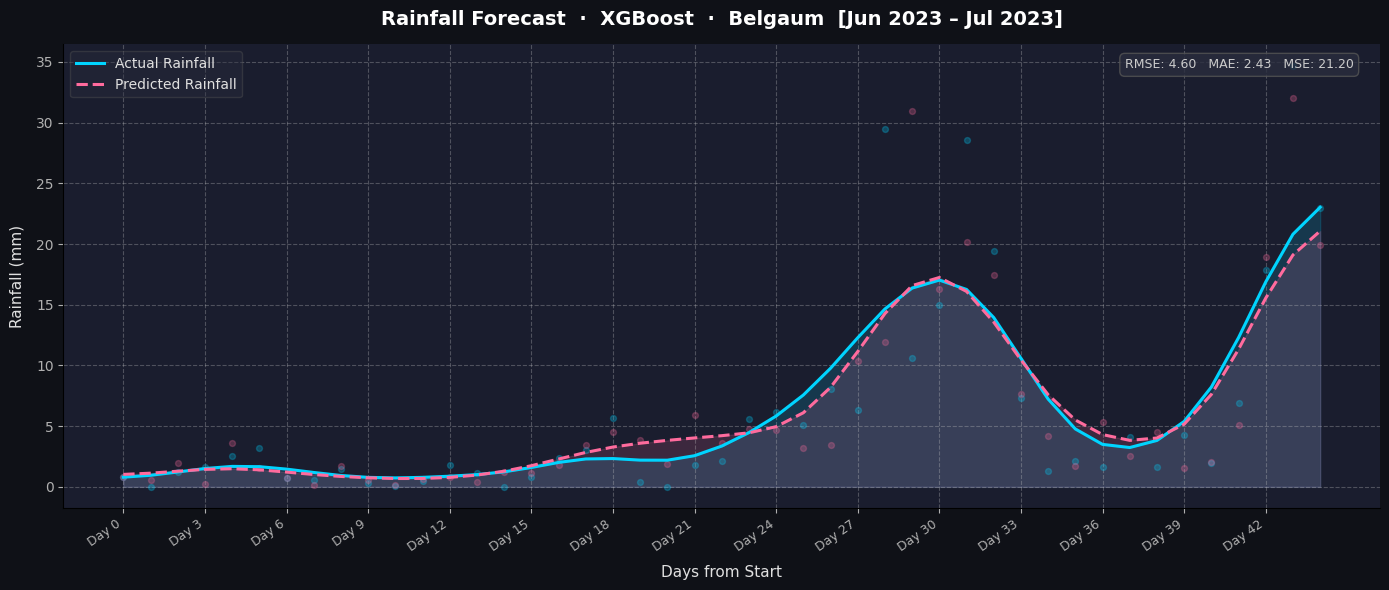

In [104]:
result_df, metrics = evaluate_station(
    model=model,
    df=df,
    station_name="Belgaum",
    start_date="2023-06-06",
    num_days=45
)